

One group in PRBB has studied a particular protein with the following sequence:

ATKAICILKGDGPVQGTLSSLSLHFEAKGDEGGDTIVITGSLTGLTEGDHGWHIHQWGDNTQGCTSAGPLFNPLSKK
LGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLLGRTMVIHEKPLVLGRGGNEELMIQNSTKKTGNAG
SRLACGVLGLAK

They are not sure about the function of this protein. 
Could you answer the following questions?:

__1) To what PFAM family this protein belongs? (fetch and rename the HMM model as "target29.hmm")__

First of all create a file called `target.fa`and paste the sequence like this:

```
>target
ATKAICILKGDGPVQGTLSSLSLHFEAKGDEGGDTIVITGSLTGLTEGDHGWHIHQWGDNTQGCTSAGPLFNPLSKK
LGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLLGRTMVIHEKPLVLGRGGNEELMIQNSTKKTGNAG
SRLACGVLGLAK
```
Then run `hmmscan`to find the PFAM family the protein belongs to:

`hmmscan /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm target.fa > targetpfam.out`

And we see that this protein belongs to a superoxide dismutase family:

```
Query:       target  [L=166]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model    Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
    3.5e-37  127.6   0.1      4e-37  127.4   0.1    1.1  1  Sod_Cu    Copper/zinc superoxide dismutase (SODC)

```



`jackhmmer --chkhmm target29_profile target.fa /mnt/NFS_UPF/soft/databases/blastdat/uniprot_sprot.fasta`


And I'll will stick to the first iterations because the exercise wants close homologs (5.2)


__2) Please align the sequence of this protein with three different  close homologs, with known structure and different sequences, using the HMM profile. (place the alignment in a file named "align29.txt")__

As it says _close homologs_ I will use `blastp` to find them. Once done, perform a multiple sequence alignment (MSA) using a specific Profile Hidden Markov Model (HMM) as a template. This ensures that the alignment of the target sequence with its homologs is guided by the conserved structural motifs of that protein family. Standard alignments can sometimes fail if the sequence identity is low. The HMM profile contains "knowledge" about which positions in a protein family are highly conserved (like active sites) and which are variable. Aligning to the profile ensures that your target sequence is matched against these important structural landmarks correctly.

- Find homologs --> `hmmsearch` 

    - Known Structure: They must have a 4-character PDB code (e.g., 1z8u).

    - Close Homologs: Look for the lowest E-values (closest to 0.0).

    - Different Sequences: Do not pick three versions of the same protein.

`hmmsearch target29_profile-1.hmm /mnt/NFS_UPF/soft/databases/blastdat/pdb_seq > target29_profile-1_pdb.out`

```
Query:       target  [M=166]
Scores for complete sequences (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Sequence Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
    4.1e-78  263.9   3.9    4.6e-78  263.7   3.9    1.0  1  1cbj_A    mol:protein length:151  PROTEIN (SUPEROXIDE DISMUTA
    4.1e-78  263.9   3.9    4.6e-78  263.7   3.9    1.0  1  1cbj_B    mol:protein length:151  PROTEIN (SUPEROXIDE DISMUTA
    4.1e-78  263.9   3.9    4.6e-78  263.7   3.9    1.0  1  1cob_A    mol:protein length:151  SUPEROXIDE DISMUTASE
    4.1e-78  263.9   3.9    4.6e-78  263.7   3.9    1.0  1  1cob_B    mol:protein length:151  SUPEROXIDE DISMUTASE
    4.1e-78  263.9   3.9    4.6e-78  263.7   3.9    1.0  1  1q0e_A    mol:protein length:151  Superoxide dismutase [Cu-Zn
    4.1e-78  263.9   3.9    4.6e-78  263.7   3.9    1.0  1  1q0e_B    mol:protein length:151  Superoxide dismutase [Cu-Zn
    4.1e-78  263.9   3.9    4.6e-78  263.7   3.9    1.0  1  1sda_B    mol:protein length:151  COPPER,ZINC SUPEROXIDE DISM
    4.1e-78  263.9   3.9    4.6e-78  263.7   3.9    1.0  1  1sda_G    mol:protein length:151  COPPER,ZINC SUPEROXIDE DISM
```

As homologs,  because they have a really singiifciant e.value, i 'll use `1cbj_A`, `1qoe_A`and `1cob_A`. Now retieve these homologs from the database of the uni:

```
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/cb/pdb1cbj.ent.gz .
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/q0/pdb1q0e.ent.gz .
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/co/pdb1cob.ent.gz .

gunzip *gz

PDBtoSplitChain.pl -i pdb1cbj.ent -o 1cbj_
PDBtoSplitChain.pl -i pdb1q0e.ent -o 1q0e_
PDBtoSplitChain.pl -i pdb1cob.ent -o 1cob_

cat target.fa > alignment2.fa
cat 1cbj_A.fa >> alignment2.fa 
cat 1q0e_A.fa >> alignment2.fa 
cat 1cob_A.fa >> alignment2.fa 



>target
ATKAICILKGDGPVQGTLSSLSLHFEAKGDEGGDTIVITGSLTGLTEGDHGWHIHQWGDNTQGCTSAGPLFNPLSKK
LGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLLGRTMVIHEKPLVLGRGGNEELMIQNSTKKTGNAG
SRLACGVLGLAK>1cbj_A 
ATKAVCVLKGDGPVQGTIHFEAKGDTVVVTGSITGLTEGDHGFHVHQFGDNTQGCTSAGPHFNPLSKKHGGPKDEERHVG
DLGNVTADKNGVAIVDIVDPLISLSGEYSIIGRTMVVHEKPDDLGRGGNEESTKTGNAGSRLACGVIGIAK
>1q0e_A 
ATKAVCVLKGDGPVQGTIHFEAKGDTVVVTGSITGLTEGDHGFHVHQFGDNTQGCTSAGPHFNPLSKKHGGPKDEERHVG
DLGNVTADKNGVAIVDIVDPLISLSGEYSIIGRTMVVHEKPDDLGRGGNEESTKTGNAGSRLACGVIGIAK
>1cob_A 
ATKAVCVLKGDGPVQGTIHFEAKGDTVVVTGSITGLTEGDHGFHVHQFGDNTQGCTSAGPHFNPLSKKHGGPKDEERHVG
DLGNVTADKNGVAIVDIVDPLISLSGEYSIIGRTMVVHEKPDDLGRGGNEESTKTGNAGSRLACGVIGIAK
```


- Alignment --> `hmmalign`(_align the target with the three homologs file  using the .hmm profile_)

`hmmalign target29_profile-1.hmm alignment2.fa > align29_2.txt`

And obtain this as a results:

```
# STOCKHOLM 1.0

target         ATKAICILKGDGPVQGTLSSLSLHFEAKGDEGGDTIVITGSLTGLTEGDHGWHIHQWGDNTQGCTSAGPLFNPLSKKLGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLLGRTMVIHEKPLVLGRGGNEELMIQNSTKKTGNAGSRLACGVLGLAK
#=GR target PP 79******************************************************************************************************************************************************************98
1cbj_A         ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDNTQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSIIGRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK
#=GR 1cbj_A PP 79**************9.....5****96....69*******************************************************************************************************98.....4.48***************97
1q0e_A         ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDNTQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSIIGRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK
#=GR 1q0e_A PP 79**************9.....5****96....69*******************************************************************************************************98.....4.48***************97
1cob_A         ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDNTQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSIIGRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK
#=GR 1cob_A PP 79**************9.....5****96....69*******************************************************************************************************98.....4.48***************97
#=GC PP_cons   79**************9*****7*****7****7*********************************************************************************************************9*****5*68***************98
#=GC RF        xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
//


```

This produces a Stockton/SELEX formatted alignment where every sequence is matched against the HMM's consensus.


__3) Do you think it will work as any of the closest homologs? (summarize your hypothesis: Show the amino-acids required for the particular function  in the previous sequence alignment with a "@" symbol on the top of the alignment in clustalw format in a file named "align29_function.aln" )__
   Example:
             @
     AAAAAAAAGAAAAAA
     AAAAAAAAAAAAAAA

If you just put the four sequences into ClustalW, it will perform a "de novo" alignment—it looks for similarities between those four specific sequences only.
By using hmmalign, you are using a profile built from thousands of sequences. This ensures that even if your homologs are diverse, the residues are aligned according to the true conserved positions of the protein family.

`aconvertMod2.pl -in h -out c < align29_2.txt > align29_function.aln`


As we used hmm to do the alignemtn and will sotre the convserved regions, it is more reliable rather tan jus tuse plain blastp. 

To know the important regions, I will take a look at `interpro` (Pfam web page)  and there I'll paste the accession number obtained in the `target29_pdb.out` and in the overview section, copy the prosite ID and paste it in the `PROSITE` and it will tell me the most important regions:

_We derived two signature patterns for this family of enzymes: the first one contains two histidine residues that bind the copper atom; the second one is located in the C-terminal section of SODC and contains a cysteine which is involved in a disulfide bond._

If we open on chimer one template, and open the MSA, we will see the important residues interacting with the ions and also it's position to put the "@" in the `align29_function.aln`.

The commands on chimera to see the interacting atoms are;

```
select Zn | Cu
Focus > "<3.5A
invert seciont --> hide ribbon (to only have the atoms)
label residues
```


![most_important_interacting atoms.png](<attachment:most_important_interacting atoms.png>)

```
CLUSTAL W(1.60) multiple sequence alignment
                                                         @  @
target  ATKAICILKGDGPVQGTLSSLSLHFEAKGDEGGDTIVITGSLTGLTEGDHGWHIHQWGDN
1cbj_A  ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDN
1q0e_A  ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDN
1cob_A  ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDN
                 @       @        @  @
target  TQGCTSAGPLFNPLSKKLGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLL
1cbj_A  TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSII
1q0e_A  TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSII
1cob_A  TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSII
              @
target  GRTMVIHEKPLVLGRGGNEELMIQNSTKKTGNAGSRLACGVLGLAK
1cbj_A  GRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK
1q0e_A  GRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK
1cob_A  GRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK 
```

As shown, the target does not have His61, His69 and His78 and those are important for zn interaction. Therefore, it will NOT work as a standard Cu/Zn Superoxide Dismutase. His have + charges, while L and V are hydrophobic aminoacids, so the activity of the aa is not conserved, therefore, the target has lost its funciton to interact with the zn ion!!!


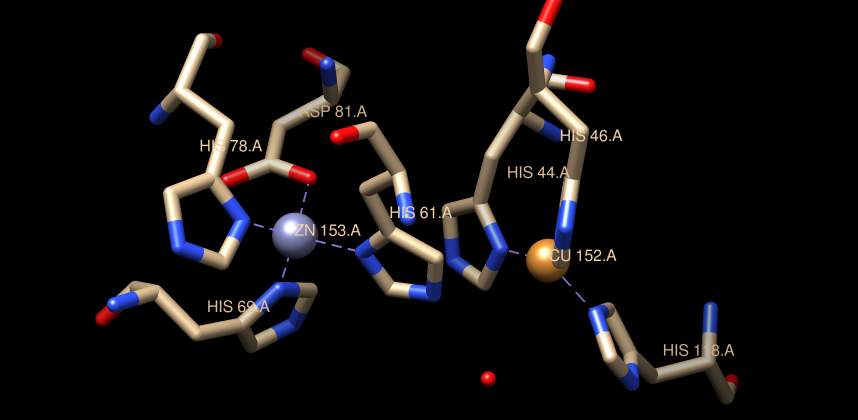

__Build the the structure of this protein by homolgy modelling.__

__4) What's the fold of this protein?__

To know the fold of the protein, we have to look at SCOP the PDB code of the best match of the target sequence. SCOP does not classify the proteins by its family (like Pfam does), but it does by its 3D structure. The best homolog for the target protein is `1cbj_A` as we obtained. In SCOP there's no results for 1cbj_A, but for a close honolog yes and it says SOD1 (Superoxide Dismutase) proteins belong to the _"Immunoglobulin-like beta-sandwich" fold._



__5) Superpose the structure of your model with one member of the same fold  (as for example one of the templates), name the file p29_fig1_superpose.pdb  and show a picture in ribbons of the superimposition in p29_fig1.jpg showing the location of heteroatoms (except water). What's the RMSD  of the CA atoms? (save the file as  p29_RMSca_superpose.txt)__

`aconvertMod2.pl -in c -out p < align29_function.aln > align29_function.pir`

```
# Homology modeling with multiple templates
from modeller import *              # Load standard Modeller classes
from modeller.automodel import *    # Load the automodel class

log.verbose()    # request verbose output
env = environ()  # create a new MODELLER environment to build this model in

# directories for input atom files
env.io.atom_files_directory = ['.', '../atom_files']

a = automodel(env,
              alnfile  = 'align29_function.pir', # alignment filename
              knowns   = ('1cbj_A', '1q0e_A', '1cob_A'),     # codes of the templates
              sequence = 'target')               # code of the target
a.starting_model= 1                 # index of the first model
a.ending_model  = 2                 # index of the last model
                                    # (determines how many models to calculate)
a.make()                            # do the actual homology modeling




>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
target.B99990001.pdb          4851.30615
target.B99990002.pdb          5178.45459
```

Will pick the one that has higher scores, whch is the first one. Open `chimera target.B99990002.pdb pdb1cbj.ent` to see the heteroatonms (cu and zn):

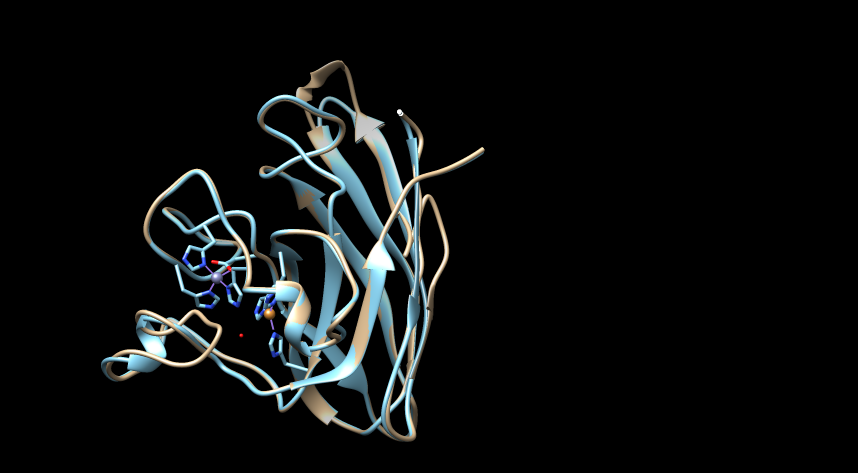

To __calculate the RMSD for the _CA_ atoms on chimera first superpose the structures on `matchmaker`> `favourites`>`replylog`:

```
Model 0 (target.B99990002.pdb) appears to be a protein without secondary structure assignments.
Automatically computing assignments using 'ksdssp' and parameter values:
  energy cutoff -0.5
  minimum helix length 3
  minimum strand length 3
Use command 'help ksdssp' for more information.
#1, chain A: superoxide dismutase
#1, chain B: superoxide dismutase
Computing secondary structure assignments for model(s) #0, #1
using ksdssp (Kabsch and Sander Define Secondary Structure
of Proteins) with the parameters:
  energy cutoff -0.5
  minimum helix length 3
  minimum strand length 3

Matchmaker target.B99990002.pdb (#0) with pdb1cbj.ent, chain A (#1), sequence alignment score = 623.3
with these parameters:
	chain pairing: bb
	Needleman-Wunsch using BLOSUM-62
	ss fraction: 0.3
	gap open (HH/SS/other) 18/18/6, extend 1
	ss matrix:  (O, S): -6 (H, O): -6 (H, H): 6 (S, S): 6 (H, S): -9 (O, O): 4
	iteration cutoff: 2
RMSD between 149 pruned atom pairs is 0.311 angstroms; (across all 151 pairs: 0.961)

Computing secondary structure assignments for model(s) #0, #1
using ksdssp (Kabsch and Sander Define Secondary Structure
of Proteins) with the parameters:
  energy cutoff -0.5
  minimum helix length 3
  minimum strand length 3

Matchmaker target.B99990002.pdb (#0) with pdb1cbj.ent, chain A (#1), sequence alignment score = 623.3
with these parameters:
	chain pairing: bb
	Needleman-Wunsch using BLOSUM-62
	ss fraction: 0.3
	gap open (HH/SS/other) 18/18/6, extend 1
	ss matrix:  (O, S): -6 (H, O): -6 (H, H): 6 (S, S): 6 (H, S): -9 (O, O): 4
	iteration cutoff: 2
RMSD between 149 pruned atom pairs is 0.311 angstroms; (across all 151 pairs: 0.961)

```

_The RMSD will tell us how different are these two proteins structurally._ 

- 0.306 Å (Pruned): This is the RMSD after Chimera "threw out" the parts that didn't align well (like floppy loops) to get the best core fit.

- 0.961 Å (All pairs): This is the RMSD for all 151 Carbon Alpha (CA) atoms.


__6) Illustrate a detail with the active site of the enzyme in the previous superposition to reinforce your discussion in question 3 (p29_fig2.jpg)__ 

```
select Cu | Zn
select #1 sel z < 3.0
```

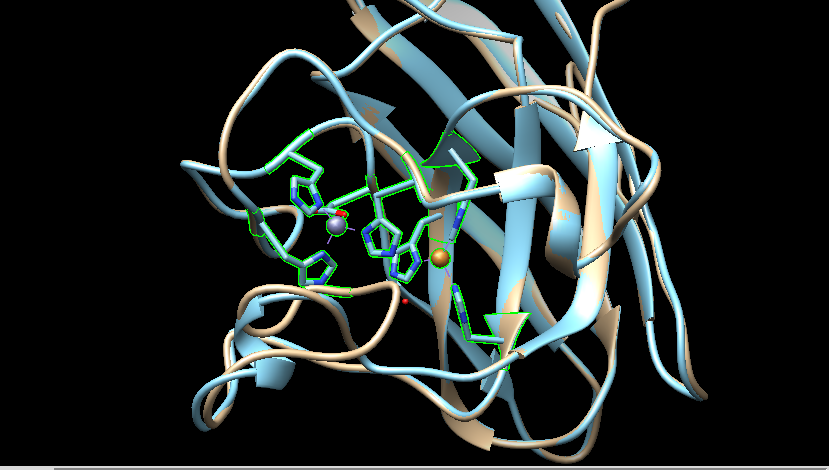


```
color hot pink sel
select #0 & sel z < 3.0
select sel z < 3.0
show sel
color red sel
```

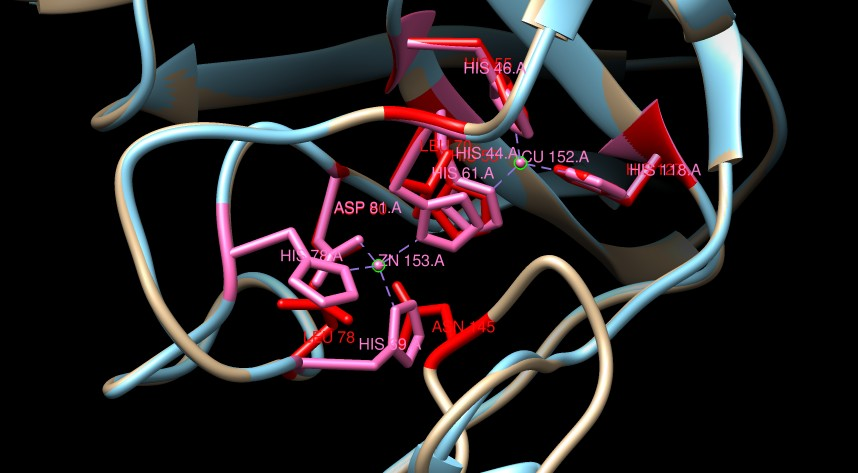


1. Configura els "Atoms to Check"

- Primer set (els metalls): Selecciona el Zn i el Cu a la pantalla i prem el botó superior Designate. Hauria de dir "2 atoms designated" (com ja tens ara).

- Segon set (el teu target beige): * A la finestra principal de Chimera, selecciona tota la teva proteïna beige (pots fer-ho per comanda amb select #1 o seleccionant-la amb el ratolí).

- Llavors, a la finestra de la captura, prem el botó que diu Designate selection as second set. Hauries de veure que el número d'àtoms del "Second set" canvia.

- Marca el "bullet" (el cercle) que diu "second set of designated atoms".

2. Ajusta els paràmetres (Clash/Contact Parameters)

Els valors que tens (0.6 i 0.4) estan pensats per detectar col·lisions (àtoms massa a prop). Per trobar contactes de coordinació (distàncies més llargues), hem de ser més permissius:

- Clica al botó contact. Això canviarà automàticament els valors a uns de més adequats (normalment posa l'overlap en valors negatius).

- Si no canvia, posa manualment: VDW overlap >= -1.0 o -1.5.

3. Visualització (Treatment of...)
Has fet bé de marcar Draw pseudobonds. Et recomano marcar també la casella Select, així sabràs exactament quines Histidines del beige estan "tocant" el metall.


Amb aquest procediment, el que estàs fent és la prova del cotó per validar si el teu model estructural (el que has generat tu, en beige) és funcionalment correcte.

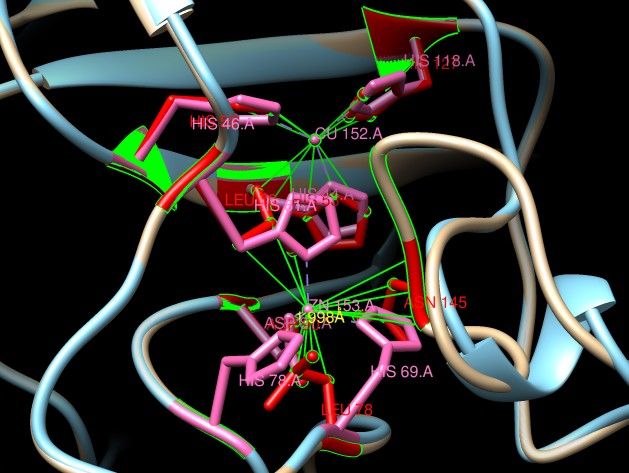

Results of `reply log` of the clashes of both target and template respectively:


```
Allowed overlap: -1.5
H-bond overlap reduction: 0
Ignore contacts between atoms separated by 4 bonds or less
Detect intra-residue contacts: False
Detect intra-molecule contacts: True

30 contacts
atom1  atom2  overlap  distance
#1 CU 152.A CU  #0 HIS 127 NE2  0.418  1.792
#1 ZN 153.A ZN  #0 LEU 70 CD1   0.050  2.430
#1 CU 152.A CU  #0 HIS 55 NE2   0.044  2.166
#1 ZN 153.A ZN  #0 ASN 145 CA   0.011  2.469
#1 ZN 153.A ZN  #0 ASP 90 OD1   -0.139  2.159
#1 CU 152.A CU  #0 HIS 127 CE1  -0.179  2.509
#1 CU 152.A CU  #0 HIS 53 ND1   -0.276  2.486
#1 ZN 153.A ZN  #0 LEU 78 CB    -0.284  2.764
#1 CU 152.A CU  #0 HIS 55 CE1   -0.415  2.745
#1 ZN 153.A ZN  #0 LEU 78 CG    -0.417  2.897
#1 ZN 153.A ZN  #0 ASP 90 CG    -0.521  3.001
#1 CU 152.A CU  #0 LEU 70 CD2   -0.638  3.088
#1 CU 152.A CU  #0 HIS 127 CD2  -0.716  3.046
#1 ZN 153.A ZN  #0 ASN 145 N    -0.813  3.053
#1 ZN 153.A ZN  #0 VAL 87 CG1   -0.857  3.337
#1 ZN 153.A ZN  #0 LEU 70 CG    -0.932  3.412
#1 CU 152.A CU  #0 HIS 53 CB    -0.936  3.386
#1 ZN 153.A ZN  #0 ASN 145 CB   -0.997  3.477
#1 CU 152.A CU  #0 HIS 55 CD2   -1.029  3.359
#1 ZN 153.A ZN  #0 VAL 87 CB    -1.035  3.515
#1 ZN 153.A ZN  #0 ASN 145 C    -1.043  3.253
#1 ZN 153.A ZN  #0 LEU 70 CB    -1.061  3.541
#1 ZN 153.A ZN  #0 LEU 78 CD2   -1.063  3.543
#1 CU 152.A CU  #0 HIS 53 CG    -1.105  3.285
#1 ZN 153.A ZN  #0 ASP 90 OD2   -1.154  3.174
#1 ZN 153.A ZN  #0 ASN 145 O    -1.235  3.255
#1 CU 152.A CU  #0 HIS 53 CE1   -1.265  3.595
#1 ZN 153.A ZN  #0 ASN 145 CG   -1.301  3.511
#1 ZN 153.A ZN  #0 ASN 145 OD1  -1.363  3.383
#1 ZN 153.A ZN  #0 GLN 144 CG   -1.413  3.893

Allowed overlap: -1.5
H-bond overlap reduction: 0
Ignore contacts between atoms separated by 4 bonds or less
Detect intra-residue contacts: False
Detect intra-molecule contacts: True

28 contacts
atom1  atom2  overlap  distance
#1 ZN 153.A ZN  #1 HIS 61.A ND1   0.276  1.964
#1 ZN 153.A ZN  #1 HIS 78.A ND1   0.242  1.998
#1 CU 152.A CU  #1 HIS 46.A NE2   0.231  1.979
#1 ZN 153.A ZN  #1 HIS 69.A ND1   0.216  2.024
#1 CU 152.A CU  #1 HIS 118.A NE2  0.212  1.998
#1 CU 152.A CU  #1 HIS 44.A ND1   0.138  2.072
#1 ZN 153.A ZN  #1 ASP 81.A OD1   0.035  1.985
#1 ZN 153.A ZN  #1 ASP 81.A CG    -0.240  2.720
#1 ZN 153.A ZN  #1 HIS 61.A CE1   -0.478  2.838
#1 ZN 153.A ZN  #1 HIS 69.A CE1   -0.492  2.852
#1 ZN 153.A ZN  #1 HIS 78.A CE1   -0.518  2.878
#1 CU 152.A CU  #1 HIS 118.A CD2  -0.540  2.870
#1 CU 152.A CU  #1 HIS 46.A CE1   -0.575  2.905
#1 CU 152.A CU  #1 HIS 118.A CE1  -0.668  2.998
#1 CU 152.A CU  #1 HIS 46.A CD2   -0.709  3.039
#1 CU 152.A CU  #1 HIS 44.A CE1   -0.722  3.052
#1 ZN 153.A ZN  #1 ASP 81.A OD2   -0.802  2.822
#1 CU 152.A CU  #1 HIS 44.A CB    -0.838  3.288
#1 CU 152.A CU  #1 HIS 44.A CG    -0.849  3.029
#1 ZN 153.A ZN  #1 HIS 61.A CG    -0.854  3.064
#1 ZN 153.A ZN  #1 HIS 78.A CG    -0.893  3.103
#1 ZN 153.A ZN  #1 HIS 61.A CB    -0.973  3.453
#1 ZN 153.A ZN  #1 HIS 69.A CG    -0.982  3.192
#1 CU 152.A CU  #1 HIS 61.A NE2   -0.986  3.196
#1 ZN 153.A ZN  #1 HIS 78.A CB    -1.037  3.517
#1 CU 152.A CU  #1 HIS 61.A CD2   -1.082  3.412
#1 ZN 153.A ZN  #1 HIS 69.A CB    -1.212  3.692
#1 CU 152.A CU  #1 HOH 163.A O    -1.470  3.500
```

The overall distance between the residues of my target are 1.96 i 2.07 Å. Això és una precisió excel·lent per a un modelat.

__7) Compare the energy of knowledge based potentials of Prosa of your model and your template(s) in p29_fig3.jpg (please keep the same colors for target and template as in p29_fig1.jpg or some reference energy_vs_sequence so I can understand your answer)__

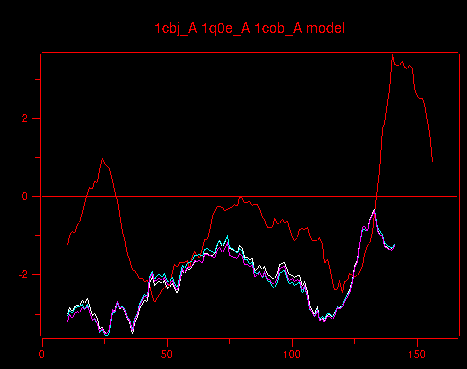

The ProSA energy profile (Figure 3) shows a clear distinction between the templates (magenta/cyan/white) and the target model (red). While the templates maintain a consistently negative energy score throughout the sequence—indicating stable, well-folded structures—the model displays two significant energy peaks above zero:

- Region ~20-30: There is an initial rise in energy.

- Region ~70-80: A noticeable peak where the energy becomes positive.

- C-terminus (Region 130-166): A very prominent peak where the energy increases sharply.

These high-energy regions correlate directly with the gaps and insertions identified in the multiple sequence alignment:

- Loop Insertions: The target sequence contains insertions (e.g., the SLSLH region near residue 25 and the C-terminal extension) that are not present in the templates (1cbj_A, 1q0e_A, 1cob_A).

- Modeling Constraints: Since Modeller relies on spatial restraints from the templates, regions with gaps or long insertions lack sufficient structural information. This results in "de novo" modeled loops that often have sub-optimal geometries or unfavorable atomic contacts, translating into the positive energy peaks observed.

- C-terminal Extension: The sharp increase at the end of the graph (residues 140-166) is expected, as this part of the target has no template to follow, likely resulting in a disordered or poorly packed tail.

Despite the local instabilities, the global energy parameters provide a positive outlook:

- Z-score (zp-comb): The model's Z-score of -6.96 is within the range characteristic of native-like proteins of this size (166 residues). Although it is less stable than the templates (which are around -9.2), it still falls within the expected distribution for experimental structures.

- Stability: The negative ep-comb (-107.84) confirms that the overall fold is energetically favorable, despite the local "stress" caused by the loops.


```

target  ATKAICILKGDGPVQGTLSSLSLHFEAKGDEGGDTIVITGSLTGLTEGDHGWHIHQWGDN
1cbj_A  ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDN
1q0e_A  ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDN
1cob_A  ATKAVCVLKGDGPVQGT-----IHFEAKG----DTVVVTGSITGLTEGDHGFHVHQFGDN

target  TQGCTSAGPLFNPLSKKLGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLL
1cbj_A  TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSII
1q0e_A  TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSII
1cob_A  TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSII

target  GRTMVIHEKPLVLGRGGNEELMIQNSTKKTGNAGSRLACGVLGLAK
1cbj_A  GRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK
1q0e_A  GRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK
1cob_A  GRTMVVHEKPDDLGRGGNEE-----S-TKTGNAGSRLACGVIGIAK
```

```
Hide & Seek on polyprotein pII3.0.short.ply - selection of parameters
molecule     seq-l zp-comb zp-pair zp-surf rk-comb rk-pair rk-surf z1-comb z1-pair z1-surf  ep-comb  ep-pair  ep-surf  em-comb  em-pair  em-surf es-comb es-pair es-surf
temp1          151   -9.28   -7.21   -6.42       1       1       1   -9.08   -7.29   -6.05  -265.02  -165.75   -30.35   141.67    49.40    28.21   43.85   29.83    9.12
temp2          151   -9.22   -7.07   -6.47       1       1       1   -9.08   -7.29   -6.05  -262.51  -161.62   -30.84   141.67    49.40    28.21   43.85   29.83    9.12
temp3          151   -9.08   -7.04   -6.30       1       1       1   -9.08   -7.29   -6.05  -256.50  -160.77   -29.26   141.67    49.40    28.21   43.85   29.83    9.12
model          166   -6.96   -4.02   -6.10       1       2       1   -5.59   -4.42   -5.11  -107.84   -44.56   -27.85   144.15    55.60    38.97   36.21   24.89   10.95
```

The model is globally correct and maintains the characteristic fold of a Superoxide Dismutase. The local high-energy peaks are a direct consequence of modeling non-conserved loops and C-terminal extensions without template guidance. To improve the model, these specific regions could be refined using loop modeling protocols or energy minimization.